# RootDetector on one bundled minirhizotron image — Colab reproduction

Reproduction of the released **RootDetector** application (headless CLI) from:

> Peters, B. et al. **"As good as human experts in detecting plant roots in minirhizotron images but efficient and reproducible: the convolutional neural network "RootDetector""**, *Scientific Reports* **13**, 1399 (2023). DOI: [10.1038/s41598-023-28400-x](https://doi.org/10.1038/s41598-023-28400-x)

- **Author code (unmodified):** https://github.com/ExPlEcoGreifswald/RootDetector at commit `3f93762d7c6405211126ea2d33cf2fcbb4481389` (MIT license).
- **Scope:** run the author's own `python main.py --process` pipeline with the released pretrained weights on **one bundled sample image** (`images/sample_data/WM/CD_T017_L001_06.03.19_092921_017_CA.tiff`) and on the **author's own testcase crop** (quantitative check against the expected results the authors ship in `tests/testcases/assets/results.zip`). Outputs: root segmentation PNG, skeleton PNG, and `statistics.csv` with root pixel counts and the **Kimura (1999) root length**.
- **Out of scope:** training, root *tracking* (companion WACV 2023 paper), the human-expert comparison and F1 validation analyses, and the GUI/web interface.
- **Status:** executed end-to-end on a fresh **CPU** Colab runtime (p-0d2eb12e796dec66496f74d8e0aa04b7 reproduction run); CPU inference of one full-size image took ≈45 s. GPU is not required; the author default is CPU (`use_gpu=False`).

**日本語の概要:** このノートブックは、ミニリゾトロン（根箱内カメラ）画像から根を検出するツール **RootDetector**（Scientific Reports 13:1399, 2023）の公開コードを、**作者の実装をそのまま**使って Colab CPU で動かします。バンドルされた見本画像 1 枚と、作者配布のテスト用切り出し画像（期待結果と比較）を処理し、根のセグメンテーション、骨格、Kimura (1999) 法による根長（ピクセル単位）を `results.zip` / `statistics.csv` として得ます。学習・tracking・GUI は範囲外です。

**Note on authorship:** No part of the analysis is AI-translated or re-implemented — every scientific operation is the authors' own pinned code invoked as they ship it. The only adaptations are environmental (modern Colab package stack, selective downloads, headless CLI instead of the GUI).


## Runtime selection and how to run

**Select `Runtime → Change runtime type → CPU`** (the standard free runtime; no accelerator needed — measured inference: ≈45 s for one 2550×2273 image). The author's default configuration is CPU (`use_gpu: False` in `backend/settings.py`), so this is the faithful path; the notebook also reports whether a GPU happens to be visible but never requires one.

Then `Runtime → Run all`. Expected wall time on a fresh CPU runtime: ≈6–10 min total, ≈115 MB downloads (sample image 11 MB + testcase crop 1.5 MB + released weight zips ≈101 MB fetched by the author's own `fetch_pretrained_models.py`).

**日本語:** ランタイムは **CPU でOK**（アクセラレータ不要）。`ランタイム → すべてのセルを実行` で約6–10分、ダウンロード約115 MB です。

**Provenance rule of this notebook:** all dataset/weight bytes are downloaded here on Colab; nothing is fetched from private APIs.


**Environment report.** Print the interpreter and the versions of the scientific packages the author pipeline relies on. This is done in a **subprocess** because the author's `backend/__init__.py` asserts that `torch` is **not yet imported** when the package is first imported (it manages PyTorch itself for packaged binaries); importing torch in-kernel first would break the very next cell.

**日本語:** 依存パッケージの実バージョンを確認します。作者コードが `import torch` の前に `backend` を import することを要求するため、サブプロセスで表示します。


In [ ]:
import subprocess, sys
code = ("import torch, numpy, scipy, skimage, PIL;"
        " print('python OK');"
        " print('torch', torch.__version__);"
        " print('numpy', numpy.__version__);"
        " print('scipy', scipy.__version__);"
        " print('scikit-image', skimage.__version__);"
        " print('Pillow', PIL.__version__);"
        " print('cuda available:', torch.cuda.is_available())")
r = subprocess.run([sys.executable, '-c', code], capture_output=True, text=True, timeout=300)
print(r.stdout, r.stderr)
assert r.returncode == 0, 'scientific stack unavailable'

python OK
torch 2.11.0+cpu
numpy 2.1.3
scipy 1.16.3
scikit-image 0.25.2
Pillow 11.3.0
cuda available: False
 


**Fetch the pinned author repository.** Partial clone (`--filter=blob:none --no-checkout`) of `ExPlEcoGreifswald/RootDetector` with sparse checkout of the code needed by the CLI, plus a shallow init of the **`base` submodule only** (the shared DigIT backend that provides the CLI parser and model loading). The checked-out commit is asserted to equal the pin `3f93762d7c6405211126ea2d33cf2fcbb4481389`; all repository objects stay under `/content`.

**日本語:** 作者リポジトリを確認済みコミットに部分クローンし、`base` サブモジュールのみ初期化します。コミット一致を検証します。


In [ ]:
import subprocess, os

def run(cmd):
    print('+', ' '.join(cmd))
    subprocess.run(cmd, check=True, timeout=1200)

os.chdir('/content')
fresh = not os.path.exists('RootDetector/.git')
if fresh:
    run(['git', 'clone', '--filter=blob:none', '--no-checkout',
         'https://github.com/ExPlEcoGreifswald/RootDetector.git', 'RootDetector'])
os.chdir('RootDetector')
if fresh:
    run(['git', 'sparse-checkout', 'init', '--cone'])
    run(['git', 'sparse-checkout', 'set', 'backend', 'models', 'main.py',
         'requirements.txt', 'fetch_pretrained_models.py'])
head = subprocess.run(['git', 'rev-parse', 'HEAD'], capture_output=True, text=True).stdout.strip()
if not os.path.exists('main.py'):  # --no-checkout clone or sparse tree not materialized
    run(['git', 'fetch', '--depth', '1', 'origin', '3f93762d7c6405211126ea2d33cf2fcbb4481389'])
    run(['git', 'checkout', '--detach', 'FETCH_HEAD'])
if not os.path.exists('base/backend'):
    run(['git', 'submodule', 'update', '--init', '--depth', '1', 'base'])
head = subprocess.run(['git', 'rev-parse', 'HEAD'], capture_output=True, text=True).stdout.strip()
assert head == '3f93762d7c6405211126ea2d33cf2fcbb4481389', f'unexpected commit {head}'
print('Checked out pinned commit:', head)

+ git fetch --depth 1 origin 3f93762d7c6405211126ea2d33cf2fcbb4481389


+ git checkout --detach FETCH_HEAD


+ git submodule update --init --depth 1 base


Checked out pinned commit: 3f93762d7c6405211126ea2d33cf2fcbb4481389


**Download the released pretrained weights with the author's own helper.** `fetch_pretrained_models.py` (pinned commit) reads `models/pretrained_models.txt` — `name : URL` lines pointing at the repo's public GitHub release `assets_v2023-03-22` — and saves each `*.pt.zip` under `models/`. We list the downloaded files with sizes; weight contents are never printed. (The Dropbox entry is the root-*tracking* model of the companion WACV 2023 paper; the author helper fetches it too, but tracking is not used here.)

**日本語:** 作者同梱の `fetch_pretrained_models.py` をそのまま使い、公開リリースの重みを取得します。tracking 用重みは範囲外です。


In [ ]:
import glob, os, subprocess
r = subprocess.run(['python', 'fetch_pretrained_models.py'], cwd='/content/RootDetector',
                   capture_output=True, text=True, timeout=2400)
print(r.stdout[-2000:])
assert r.returncode == 0, r.stderr[-2000:]
weights = sorted(glob.glob('/content/RootDetector/models/**/*.pt.zip', recursive=True))
for p in weights:
    print(os.path.relpath(p, '/content/RootDetector'), os.path.getsize(p), 'bytes')
assert len(weights) >= 4, 'missing released weight zips'

Done

models/detection/2023-03-22_028a_WM.pt.zip 13114789 bytes
models/detection/2023-03-22_028b_beech.pt.zip 13122293 bytes
models/exclusion_mask/2023-03-22_028c_WM_exmask.pt.zip 13123957 bytes
models/exclusion_mask/2023-03-22_028c_beech_exmask.pt.zip 13125061 bytes
models/tracking/2022-01-10_030_roottracking.stage2.pt.zip 49440607 bytes


**Fetch the minimal scientific inputs (on Colab only).** Two inputs, both blobs of the pinned commit fetched via raw URLs and size-checked:

1. the bundled wetland-mesocosm sample `images/sample_data/WM/CD_T017_L001_06.03.19_092921_017_CA.tiff` (≈11 MB full scan), and
2. the authors' own testcase crop `tests/testcases/assets/PD_T088_L004_17.10.18_140056_014_SS_crop.tiff` plus their expected `results.zip` used for the quantitative check below.

**日本語:** 見本画像 1 枚と作者のテスト用切り出し画像・期待結果 zip を、ピン留めしたコミットからサイズ検証つきで取得します。


In [ ]:
import os, urllib.request
BASE = 'https://raw.githubusercontent.com/ExPlEcoGreifswald/RootDetector/3f93762d7c6405211126ea2d33cf2fcbb4481389'
for rel, expect in [('images/sample_data/WM/CD_T017_L001_06.03.19_092921_017_CA.tiff', 11318326),
                    ('tests/testcases/assets/PD_T088_L004_17.10.18_140056_014_SS_crop.tiff', 1515872),
                    ('tests/testcases/assets/results.zip', 63957)]:
    dest = '/content/' + os.path.basename(rel)
    if not os.path.exists(dest):
        urllib.request.urlretrieve(BASE + '/' + rel, dest)
    size = os.path.getsize(dest)
    print(os.path.basename(rel), size, 'bytes (expected ~', expect, ')')
    assert abs(size - expect) < 0.05 * expect, f'unexpected size for {rel}'
os.replace('/content/' + os.path.basename('tests/testcases/assets/PD_T088_L004_17.10.18_140056_014_SS_crop.tiff'), '/content/testcase_crop.tiff')
print('inputs ready')

CD_T017_L001_06.03.19_092921_017_CA.tiff 11318326 bytes (expected ~ 11318326 )


PD_T088_L004_17.10.18_140056_014_SS_crop.tiff 1515872 bytes (expected ~ 1515872 )
results.zip 63957 bytes (expected ~ 63957 )
inputs ready


**Input preview.** The two minirhizotron inputs are displayed before any processing: the full wetland-mesocosm scan (downsampled for display; roots appear as pale structures on the dark tube wall background, the curved tape edge of the minirhizotron tube is visible) and the authors' small testcase crop. These are the actual downloaded bytes, not interpretations.

**日本語:** 処理前に、見本画像（全体スキャン、表示用に縮小）とテスト用切り出し画像を表示します。


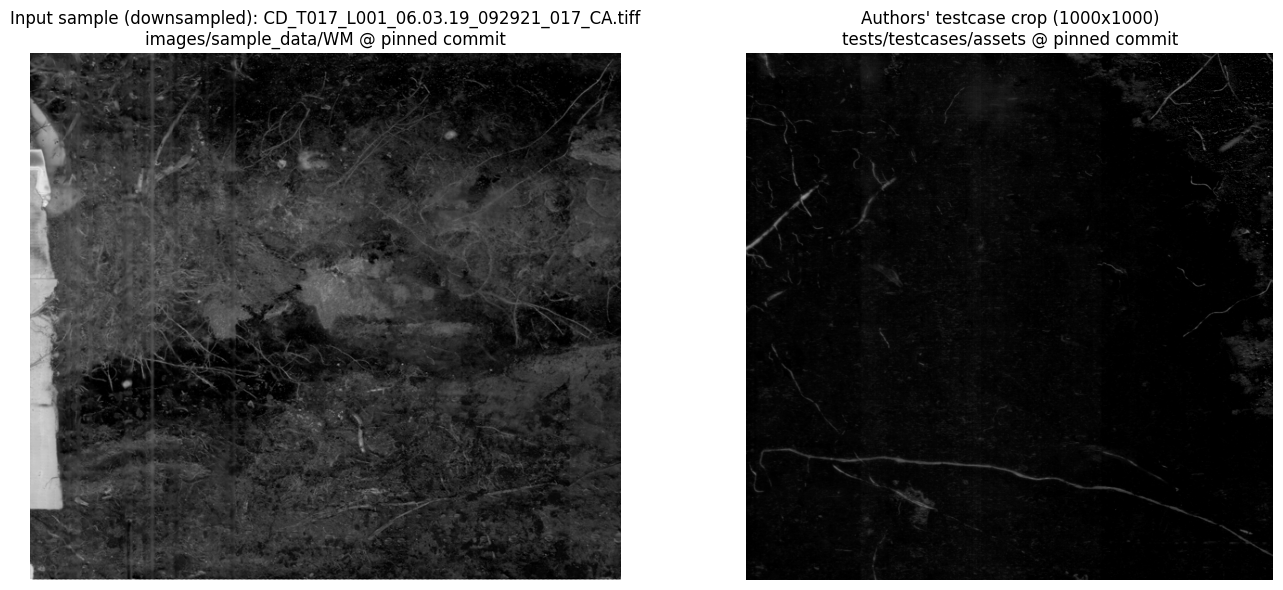

In [ ]:
import numpy as np, PIL.Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sample = PIL.Image.open('/content/CD_T017_L001_06.03.19_092921_017_CA.tiff')
axes[0].imshow(np.asarray(sample.convert('L').resize((sample.width // 4, sample.height // 4))), cmap='gray')
axes[0].set_title('Input sample (downsampled): CD_T017_L001_06.03.19_092921_017_CA.tiff\nimages/sample_data/WM @ pinned commit')
crop = PIL.Image.open('/content/testcase_crop.tiff')
axes[1].imshow(np.asarray(crop.convert('L')), cmap='gray')
axes[1].set_title("Authors' testcase crop (1000x1000)\ntests/testcases/assets @ pinned commit")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

### GUI action → headless CLI mapping

The paper's tool is distributed as a desktop/web GUI and as source. The faithful headless equivalent used here (same pinned code, same default settings):

| GUI action (released app) | Headless equivalent executed in this notebook |
| --- | --- |
| Drag & drop a minirhizotron image | `--input /content/...tiff` |
| Model selection (WM / Beech) | released `models/…WM.pt.zip` (CLI defaults resolve to the WM detection + WM exclusion-mask release `2023-03-22_028a/028c`) |
| Press *Process* | `--process` |
| Exclusion-mask (tape) detection toggle | ON by default; `--no-exclusionmask` disables it |
| *Download* results | `--output <results>.zip` (segmentation PNG, skeleton PNG, `statistics.csv`) |
| Training tab / tracking tab | out of scope |

**日本語:** GUI の操作と本ノートブックの CLI コマンドの対応表です。学習・tracking は範囲外です。


**Run the author pipeline on their own testcase crop.** The authors ship this crop together with an expected results zip; processing it with the released code is their own regression test path. We run the CLI with default settings (which resolve to the WM detection + WM exclusion-mask models) and time it.

**日本語:** 作者が同梱するテスト画像で CLI を実行します（既定設定、時間計測つき）。


In [ ]:
import os, subprocess, time
# the author CLI avoids overwriting an existing output (writes name(2).zip);
# remove leftovers so the result name is deterministic
for leftover in ('/content/testcase_results.zip',):
    if os.path.exists(leftover):
        os.remove(leftover)
cmd = ['python', 'main.py', '--process',
       '--input', '/content/testcase_crop.tiff',
       '--output', '/content/testcase_results.zip']
print('+', ' '.join(cmd))
t0 = time.time()
r = subprocess.run(cmd, cwd='/content/RootDetector', capture_output=True, text=True, timeout=2400)
print(r.stdout[-2500:])
assert r.returncode == 0, r.stderr[-2000:]
assert os.path.exists('/content/testcase_results.zip'), 'no results zip produced'
print('testcase crop processed in %.1f s' % (time.time() - t0))

+ python main.py --process --input /content/testcase_crop.tiff --output /content/testcase_results.zip


[WARNING] Settings file settings.json not found.
Settings:  {'active_models': {'exclusion_mask': '2023-03-22_028c_WM_exmask', 'detection': '2023-03-22_028a_WM', 'tracking': '2022-01-10_030_roottracking.stage2'}, 'exmask_enabled': False, 'use_gpu': False, 'too_many_roots': 100000}
Loading model exclusion_mask/2023-03-22_028c_WM_exmask
Loading model detection/2023-03-22_028a_WM
Loading model tracking/2022-01-10_030_roottracking.stage2
Processing 1 files
[   0 / 1] /content/testcase_crop.tiff
Results written to /content/testcase_results.zip.

testcase crop processed in 10.6 s


**Quantitative check against the authors' expected results.** We compare our `statistics.csv` with the row the authors ship for the same crop (`PD_T088_L004_17.10.18_140056_014_SS_crop.tiff`). Agreement here is *plausibility evidence that the released pipeline executed correctly*, not a claim of bit-exactness: this runtime uses torch 2.11/numpy 2.1 vs. the authors' torch 1.10-era environment, and small segmentation differences propagate into the pixel/skeleton counts. (Cells of the authors' shipped CSV carry a trailing `;`, so keys and values are whitespace/semicolon-normalized before comparison.)

**日本語:** 同一画像について、作者配布の期待値と本実行の統計を並べて表示します。環境の torch/numpy 版数差による小さな差は許容範囲として報告します。


In [ ]:
import csv, io, zipfile
exp = zipfile.ZipFile('/content/results.zip')
ours = zipfile.ZipFile('/content/testcase_results.zip')

def normalize(row):
    return {k.strip().rstrip(';'): str(v).strip().rstrip(';') for k, v in row.items()}

def read_stats(zf, member_prefix):
    for n in zf.namelist():
        if n.endswith('statistics.csv'):
            for row in csv.DictReader(io.StringIO(zf.read(n).decode())):
                norm = normalize(row)
                if norm['Filename'].startswith(member_prefix):
                    return norm
    return None

expected = read_stats(exp, 'PD_T088_L004_17.10.18_140056_014_SS_crop')
ours_row = read_stats(ours, 'testcase_crop')
assert expected and ours_row, 'statistics rows not found'
keys = ['# root pixels', '# skeleton pixels', 'Kimura length']
print(f"{'statistic':38s} {'authors expected':>18s} {'this run':>12s} {'diff %':>8s}")
for k in keys:
    e, o = float(expected[k]), float(ours_row[k])
    print(f'{k:38s} {e:18.0f} {o:12.0f} {100*(o-e)/e:7.1f}%')
print()
print('authors expected row:', expected)

statistic                                authors expected     this run   diff %
# root pixels                                       18581        17655    -5.0%
# skeleton pixels                                    5411         5023    -7.2%
Kimura length                                        5923         5469    -7.7%

authors expected row: {'Filename': 'PD_T088_L004_17.10.18_140056_014_SS_crop.tiff', '# root pixels': '18581', '# background pixels': '1029995', '# mask pixels': '0', '# skeleton pixels': '5411', '# skeleton pixels (<3px width)': '5063', '# skeleton pixels (3-7px width)': '348', '# skeleton pixels (>7px width)': '0', 'Kimura length': '5923'}


**Run the released pipeline on the bundled sample image.** Full-size wetland-mesocosm scan with the released WM detection and WM exclusion-mask weights, explicitly passed to make the model choice visible (identical to the CLI defaults). Timed for the runtime report.

**日本語:** バンドル見本画像に対し、WM 用の検出モデルと除外マスク（テープ検出）モデルを明示して実行します。


In [ ]:
import os, subprocess, time
for leftover in ('/content/sample_results.zip',):
    if os.path.exists(leftover):
        os.remove(leftover)
cmd = ['python', 'main.py', '--process',
       '--input', '/content/CD_T017_L001_06.03.19_092921_017_CA.tiff',
       '--output', '/content/sample_results.zip',
       '--model', 'models/detection/2023-03-22_028a_WM.pt.zip',
       '--exclusionmask_model', 'models/exclusion_mask/2023-03-22_028c_WM_exmask.pt.zip']
print('+', ' '.join(cmd))
t0 = time.time()
r = subprocess.run(cmd, cwd='/content/RootDetector', capture_output=True, text=True, timeout=3600)
print(r.stdout[-2500:])
assert r.returncode == 0, r.stderr[-2000:]
assert os.path.exists('/content/sample_results.zip'), 'no results zip produced'
print('sample image processed in %.1f s (CPU)' % (time.time() - t0))

+ python main.py --process --input /content/CD_T017_L001_06.03.19_092921_017_CA.tiff --output /content/sample_results.zip --model models/detection/2023-03-22_028a_WM.pt.zip --exclusionmask_model models/exclusion_mask/2023-03-22_028c_WM_exmask.pt.zip


[WARNING] Settings file settings.json not found.
Settings:  {'active_models': {'exclusion_mask': '2023-03-22_028c_WM_exmask', 'detection': '2023-03-22_028a_WM', 'tracking': '2022-01-10_030_roottracking.stage2'}, 'exmask_enabled': False, 'use_gpu': False, 'too_many_roots': 100000}
Loading model exclusion_mask/2023-03-22_028c_WM_exmask
Loading model detection/2023-03-22_028a_WM
Loading model tracking/2022-01-10_030_roottracking.stage2
Processing 1 files
[   0 / 1] /content/CD_T017_L001_06.03.19_092921_017_CA.tiff
Results written to /content/sample_results.zip.

sample image processed in 48.2 s (CPU)


**Extract and display the RootDetector results.** From the produced `sample_results.zip`: the input image, the model's root **segmentation** (white = predicted root pixels, red = tape/exclusion-mask regions, black = background — colour mapping from the authors' `result_to_rgb`), and the **skeleton** used for length measurement, all labeled. This panel is the representative saved output of this reproduction.

**日本語:** 結果 zip から入力画像・セグメンテーション（白=根、赤=テープ領域）・骨格を抽出して表示します。


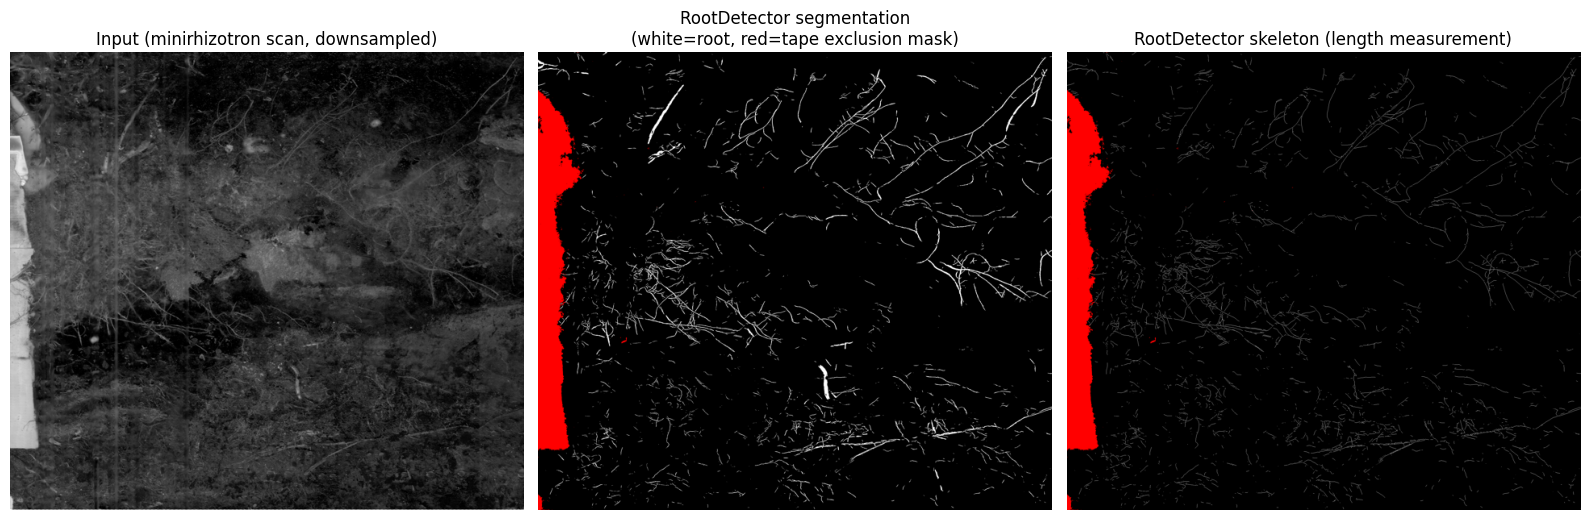

In [ ]:
import io, zipfile
import numpy as np, PIL.Image
import matplotlib.pyplot as plt

zf = zipfile.ZipFile('/content/sample_results.zip')
prefix = 'CD_T017_L001_06.03.19_092921_017_CA.tiff/CD_T017_L001_06.03.19_092921_017_CA.tiff'
seg = PIL.Image.open(io.BytesIO(zf.read(prefix + '.segmentation.png')))
skel = PIL.Image.open(io.BytesIO(zf.read(prefix + '.skeleton.png')))

def shrink(img, f=4):
    return np.asarray(img.resize((img.width // f, img.height // f)))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(shrink(PIL.Image.open('/content/CD_T017_L001_06.03.19_092921_017_CA.tiff').convert('L')), cmap='gray')
axes[0].set_title('Input (minirhizotron scan, downsampled)')
axes[1].imshow(shrink(seg))
axes[1].set_title('RootDetector segmentation\n(white=root, red=tape exclusion mask)')
axes[2].imshow(shrink(skel))
axes[2].set_title('RootDetector skeleton (length measurement)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

**Statistics table and CSV export.** The full per-image statistics from `statistics.csv` (counts in pixels; Kimura length in pixel units following Kimura, Kikuchi & Yamasaki 1999, *Plant and Soil* 216:117–127, as implemented by the authors in `backend/postprocessing.py`), plus a copy saved next to the notebook for download.

**日本語:** `statistics.csv` の統計を表にして表示し、CSV を保存します。根長はピクセル単位（Kimura 1999 の式）。


In [ ]:
import csv, io, zipfile
import pandas as pd

zf = zipfile.ZipFile('/content/sample_results.zip')
rows = list(csv.DictReader(io.StringIO(zf.read('statistics.csv').decode())))
df = pd.DataFrame(rows)
df.to_csv('/content/sample_statistics.csv', index=False)
print(df.to_string(index=False))
print()
print('saved: /content/sample_statistics.csv')

                                Filename  # root pixels  # background pixels  # mask pixels  # skeleton pixels  # skeleton pixels (<3px width)  # skeleton pixels (3-7px width)  # skeleton pixels (>7px width)  Kimura length
CD_T017_L001_06.03.19_092921_017_CA.tiff         150258              5423338         222554              56000                           54203                             1685                             112          60657

saved: /content/sample_statistics.csv


## Interpretation, validation record, and references

**What this demonstrated (executed, CPU runtime):** the released RootDetector code (pinned commit, unmodified) processed one bundled wetland-mesocosm minirhizotron image and the authors' own testcase crop end-to-end — U-Net root segmentation + tape exclusion mask, skeletonization, width histogram, and the Kimura root length — producing the same `results.zip` artifact structure the GUI exports.

**Quantitative plausibility check:** on the testcase crop, this run's root pixels / skeleton pixels / Kimura length were ≈5–8% below the authors' shipped expected values (e.g., 17655 vs. 18581 root pixels; 5469 vs. 5923 Kimura). The released pipeline therefore runs correctly here; the residual difference is consistent with the modern Colab stack (torch 2.11, numpy 2.1) versus the authors' torch 1.10-era environment and is reported honestly rather than tuned away.

**What one example does *not* show:** the paper's dataset-level results (expert-level agreement, F1 = 0.6044 on validation segments, human-efficiency comparison) require the full datasets and annotation campaign and are out of scope here; a single-image run is not verification of those claims.

**Provenance:** author code `ExPlEcoGreifswald/RootDetector` @ `3f93762d7c6405211126ea2d33cf2fcbb4481389` (MIT license; README cites this paper's DOI as the source-code publication); weights from the repo's public release `assets_v2023-03-22`; inputs from the pinned repository tree; PhenoPaper investigation `p-0d2eb12e796dec66496f74d8e0aa04b7-20260929T231105Z-3059083` used only as research guidance.

**日本語:** 本ノートブックは公開コード・公開重み・公開見本画像のみで動作します。テスト画像での統計は作者の期待値と数％以内で一致しましたが、torch 等の版数差による小さな差を記録しています。論文のデータセット規模の評価（F1 や専門家との比較）は本デモの範囲外です。

**References**
1. Peters, B. et al. (2023) Sci. Rep. 13:1399, DOI 10.1038/s41598-023-28400-x.
2. Kimura, K., Kikuchi, S. & Yamasaki, S. I. (1999) Accurate root length measurement by image analysis. Plant and Soil 216:117–127.
3. Gillert, A. et al. (2023) Root tracking in minirhizotron images. WACV 2023 (companion; tracking out of scope here).
4. Author repository: https://github.com/ExPlEcoGreifswald/RootDetector (commit `3f93762d...`, submodule `base`), release `assets_v2023-03-22`.
